In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from windfield import WindField
from tracer import solver, initial_velocity, fetch_wind_data

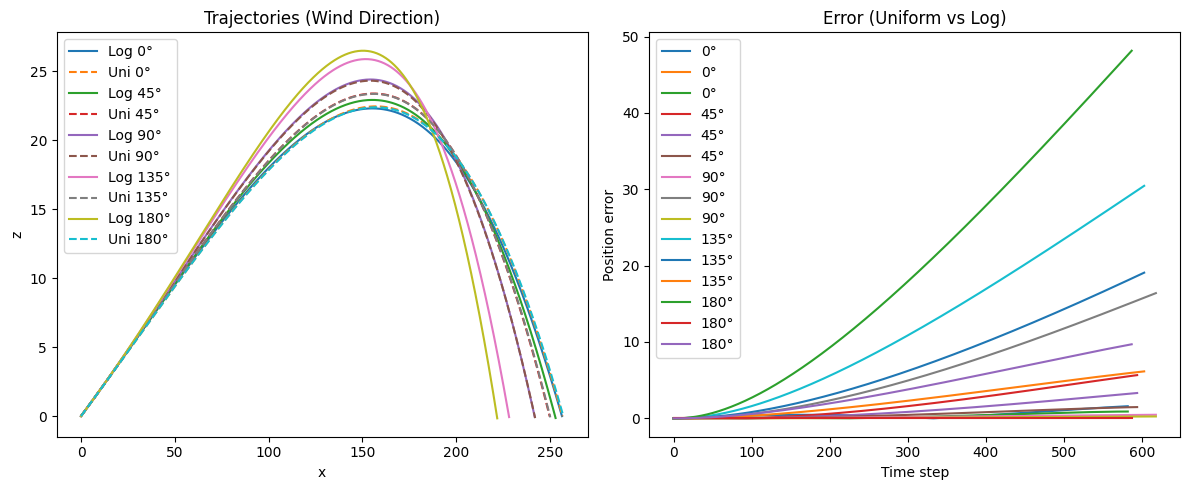

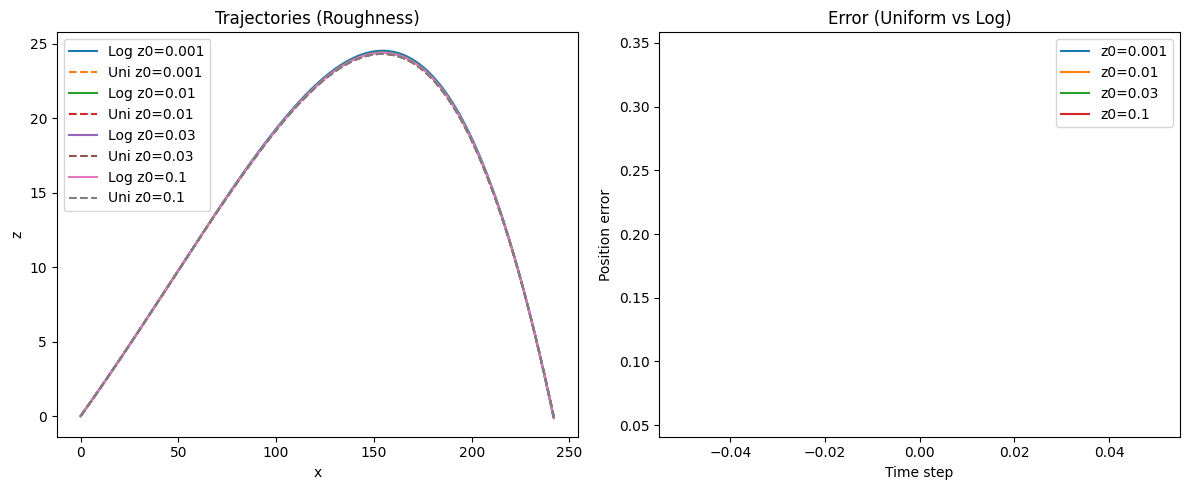

In [52]:
# --- INPUTS ---
shot_speed = 76.44384
shot_angle = 10.4
shot_spin = 2545
P0 = [0, 0, 0]

# --- FUNCTION ---
def run_simulation(direction=90, z0=0.03):
    # Log wind
    log_wind = WindField(nx=300, ny=500, nz=100,
                         direction=direction, profile='log', z0=z0)

    log_V0 = initial_velocity(speed=shot_speed, angle=shot_angle)
    log_W0 = np.array([0, -shot_spin, 0])
    log_t, log_p, log_v, log_w = solver(P0, log_V0, log_W0, log_wind, dt=0.01)

    upper_bound = max(log_p[:, 2])

    # Compute equivalent uniform wind
    wind_collect = []
    for i in range(max(1, round(upper_bound))):
        wind_collect.append(log_wind.get_point(0, 0, i)['velocity'][0])

    U_ref_uni = sum(wind_collect) / len(wind_collect)

    # Uniform wind
    uni_wind = WindField(nx=300, ny=500, nz=100,
                         direction=direction, profile='uniform', U_ref=U_ref_uni)

    uni_V0 = initial_velocity(speed=shot_speed, angle=shot_angle)
    uni_W0 = np.array([0, -shot_spin, 0])
    uni_t, uni_p, uni_v, uni_w = solver(P0, uni_V0, uni_W0, uni_wind, dt=0.01)

    return log_p, uni_p

#  Wind direction

directions = [0, 45, 90, 135, 180]

# Simulation
dir_results = {}
for d in directions:
    dir_results[d] = run_simulation(direction=d, z0=0.03)

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Trajectory plots
for d in directions:
    log_p, uni_p = dir_results[d]

    ax1.plot(log_p[:, 0], log_p[:, 2], label=f'Log {d}°')
    ax1.plot(uni_p[:, 0], uni_p[:, 2], '--', label=f'Uni {d}°')

ax1.set_xlabel("x")
ax1.set_ylabel("z")
ax1.set_title("Trajectories (Wind Direction)")
ax1.legend()

# --- RIGHT: error ---
for d in directions:
    log_p, uni_p = dir_results[d]

    min_len = min(len(log_p), len(uni_p))
    error = abs(uni_p[:min_len] - log_p[:min_len])
    ax2.plot(error, label=f'{d}°')

ax2.set_xlabel("Time step")
ax2.set_ylabel("Position error")
ax2.set_title("Error (Uniform vs Log)")
ax2.legend()

plt.tight_layout()
plt.show()


# Roughness

roughness_values = [0.001, 0.01, 0.03, 0.1]

# Simulation
rough_results = {}
for z in roughness_values:
    rough_results[z] = run_simulation(direction=90, z0=z)

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- LEFT: trajectories ---
for z in roughness_values:
    log_p, uni_p = rough_results[z]

    ax1.plot(log_p[:, 0], log_p[:, 2], label=f'Log z0={z}')
    ax1.plot(uni_p[:, 0], uni_p[:, 2], '--', label=f'Uni z0={z}')

ax1.set_xlabel("x")
ax1.set_ylabel("z")
ax1.set_title("Trajectories (Roughness)")
ax1.legend()

# --- RIGHT: error ---
for z in roughness_values:
    log_p, uni_p = rough_results[z]

    min_len = min(len(log_p), len(uni_p))
    error = abs(uni_p[-1, 0] - log_p[-1, 0])
    ax2.plot(error, label=f'z0={z}')

ax2.set_xlabel("Time step")
ax2.set_ylabel("Position error")
ax2.set_title("Error (Uniform vs Log)")
ax2.legend()

plt.tight_layout()
plt.show()

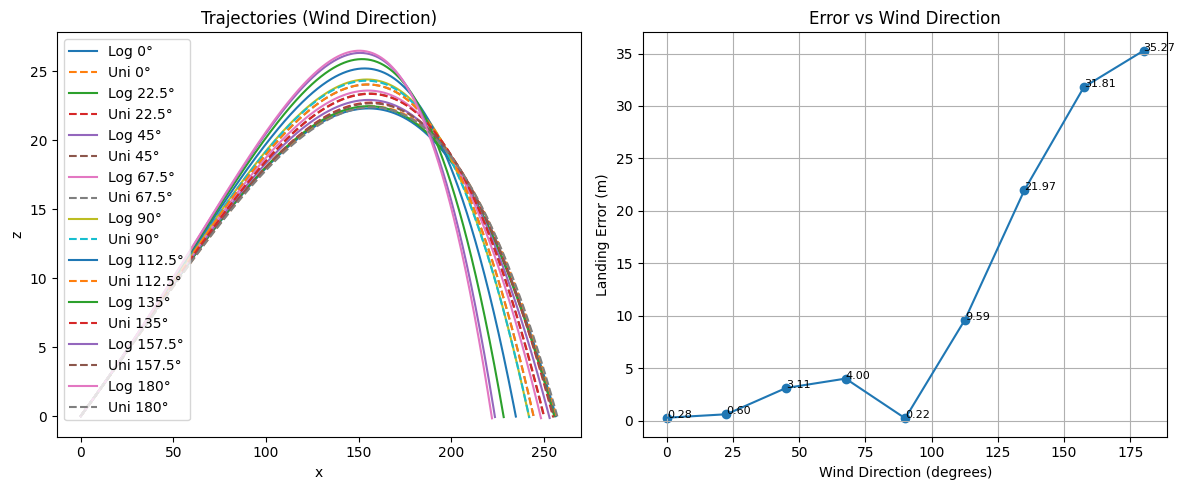

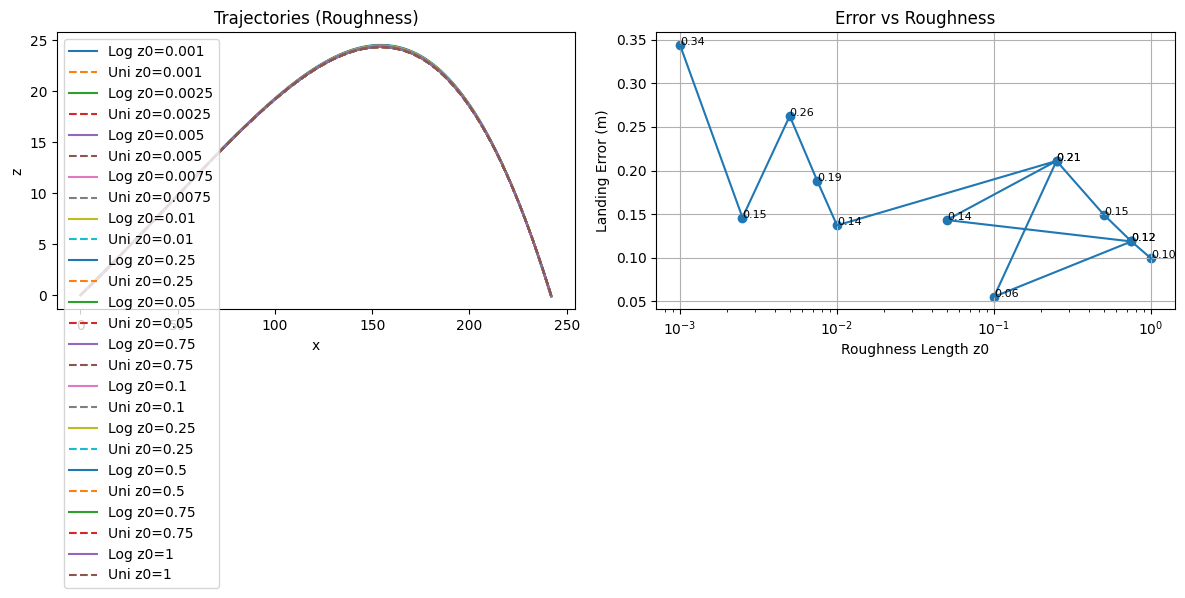

In [53]:
# --- INPUTS ---
shot_speed = 76.44384
shot_angle = 10.4
shot_spin = 2545
P0 = [0, 0, 0]

# --- FUNCTION ---
def run_simulation(direction=90, z0=0.03):
    # Log wind
    log_wind = WindField(nx=300, ny=500, nz=100,
                         direction=direction, profile='log', z0=z0)

    log_V0 = initial_velocity(speed=shot_speed, angle=shot_angle)
    log_W0 = np.array([0, -shot_spin, 0])
    log_t, log_p, log_v, log_w = solver(P0, log_V0, log_W0, log_wind, dt=0.01)

    upper_bound = max(log_p[:, 2])

    # Compute equivalent uniform wind
    wind_collect = []
    for i in range(max(1, round(upper_bound))):
        wind_collect.append(log_wind.get_point(0, 0, i)['velocity'][0])

    U_ref_uni = sum(wind_collect) / len(wind_collect)

    # Uniform wind
    uni_wind = WindField(nx=300, ny=500, nz=100,
                         direction=direction, profile='uniform', U_ref=U_ref_uni)

    uni_V0 = initial_velocity(speed=shot_speed, angle=shot_angle)
    uni_W0 = np.array([0, -shot_spin, 0])
    uni_t, uni_p, uni_v, uni_w = solver(P0, uni_V0, uni_W0, uni_wind, dt=0.01)

    return log_p, uni_p


# =========================================================
# 🌬️ WIND DIRECTION
# =========================================================

directions = [0, 22.5, 45,67.5, 90, 112.5, 135, 157.5, 180]

dir_results = {}
dir_errors = []

for d in directions:
    log_p, uni_p = run_simulation(direction=d, z0=0.03)
    dir_results[d] = (log_p, uni_p)

    # ✅ single scalar error (landing distance)
    error = abs(uni_p[-1, 0] - log_p[-1, 0])
    dir_errors.append(error)

# --- PLOTTING ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# LEFT: trajectories
for d in directions:
    log_p, uni_p = dir_results[d]

    ax1.plot(log_p[:, 0], log_p[:, 2], label=f'Log {d}°')
    ax1.plot(uni_p[:, 0], uni_p[:, 2], '--', label=f'Uni {d}°')

ax1.set_xlabel("x")
ax1.set_ylabel("z")
ax1.set_title("Trajectories (Wind Direction)")
ax1.legend()

# RIGHT: scatter error vs direction
ax2.scatter(directions, dir_errors)
ax2.plot(directions, dir_errors)

for x, y in zip(directions, dir_errors):
    ax2.text(x, y, f"{y:.2f}", fontsize=8)

ax2.set_xlabel("Wind Direction (degrees)")
ax2.set_ylabel("Landing Error (m)")
ax2.set_title("Error vs Wind Direction")
ax2.grid()

plt.tight_layout()
plt.show()


# =========================================================
# 🌾 ROUGHNESS
# =========================================================

roughness_values = [0.001, 0.0025, 0.005, 0.0075, 0.01, 0.25, 0.05, 0.75 ,0.1, 0.25, 0.5, 0.75, 1]

rough_results = {}
rough_errors = []

for z in roughness_values:
    log_p, uni_p = run_simulation(direction=90, z0=z)
    rough_results[z] = (log_p, uni_p)

    error = abs(uni_p[-1, 0] - log_p[-1, 0])
    rough_errors.append(error)

# --- PLOTTING ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# LEFT: trajectories
for z in roughness_values:
    log_p, uni_p = rough_results[z]

    ax1.plot(log_p[:, 0], log_p[:, 2], label=f'Log z0={z}')
    ax1.plot(uni_p[:, 0], uni_p[:, 2], '--', label=f'Uni z0={z}')

ax1.set_xlabel("x")
ax1.set_ylabel("z")
ax1.set_title("Trajectories (Roughness)")
ax1.legend()

# RIGHT: scatter error vs roughness
ax2.scatter(roughness_values, rough_errors)
ax2.plot(roughness_values, rough_errors)

for x, y in zip(roughness_values, rough_errors):
    ax2.text(x, y, f"{y:.2f}", fontsize=8)

ax2.set_xscale("log")  # ✅ important
ax2.set_xlabel("Roughness Length z0")
ax2.set_ylabel("Landing Error (m)")
ax2.set_title("Error vs Roughness")
ax2.grid()

plt.tight_layout()
plt.show()